# Naive Bayes TF IDF— MBTI Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).
Adjust file paths if your working directory differs from the repository root.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score



In [43]:
# --- STEP 1: Load the CSV ---
print("🔄 Loading data from CSV...")

# 1. Find the file (Teammate-Safe)
current_dir = Path.cwd()
csv_path = None

# Search for 'preprocessed_data.csv' in current and parent folders
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break

# Check if csv_path was found
if csv_path is None:
    raise FileNotFoundError(f"❌ Could not find 'preprocessed_data.csv' in current directory or parent folders")

print(f"📂 Found CSV at: {csv_path}")

🔄 Loading data from CSV...
📂 Found CSV at: c:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv


In [44]:
# 2. Read the CSV
df = pd.read_csv(csv_path)

# --- THE CHANGE: Explicitly selecting columns based on your snippet ---
# Your snippet showed: type, posts, no. of. words, type_encoded
print(f"   Columns found: {df.columns.tolist()}")

text_col = 'posts' 
target_col = 'type'

# Sanity check to ensure these columns exist before proceeding
if text_col not in df.columns or target_col not in df.columns:
    raise ValueError(f"❌ Error: Expected columns '{text_col}' and '{target_col}' but found {df.columns.tolist()}")

print(f"   Using columns: Text='{text_col}', Target='{target_col}'")

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col]) 

# --- STEP 2: Vectorization ---
print("\n🧮 Vectorizing text (TF-IDF)... This might take a minute...")
# We keep max_features=5000 for speed
# Note: 'eostokendot' and other tokens will be handled automatically by TF-IDF (low weight if common)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

X = tfidf.fit_transform(df[text_col])
y = df[target_col].values # This contains strings like "INFJ", "ENTP"

print(f"✅ Data Ready! Features shape: {X.shape}")

   Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']
   Using columns: Text='posts', Target='type'

🧮 Vectorizing text (TF-IDF)... This might take a minute...
✅ Data Ready! Features shape: (8462, 2000)



🚀 Starting Naive Bayes Training...

--- Processing I vs E ---
   Train Accuracy: 73.02%
   Test Accuracy:  69.70%
   Difference:     3.31%
📊 Macro F1-Score: 0.6956
   Confusion Matrix:
[[ 821  485]
 [ 307 1001]]

--- Processing N vs S ---
   Train Accuracy: 75.61%
   Test Accuracy:  73.54%
   Difference:     2.07%
📊 Macro F1-Score: 0.7339
   Confusion Matrix:
[[ 960  526]
 [ 245 1183]]

--- Processing T vs F ---
   Train Accuracy: 76.08%
   Test Accuracy:  73.77%
   Difference:     2.32%
📊 Macro F1-Score: 0.7363
   Confusion Matrix:
[[608 303]
 [175 736]]

--- Processing J vs P ---
   Train Accuracy: 68.79%
   Test Accuracy:  62.38%
   Difference:     6.41%
   ⚠️  Possible overfitting detected!
📊 Macro F1-Score: 0.6238
   Confusion Matrix:
[[639 377]
 [390 633]]

📊 Generating Bar Graph...


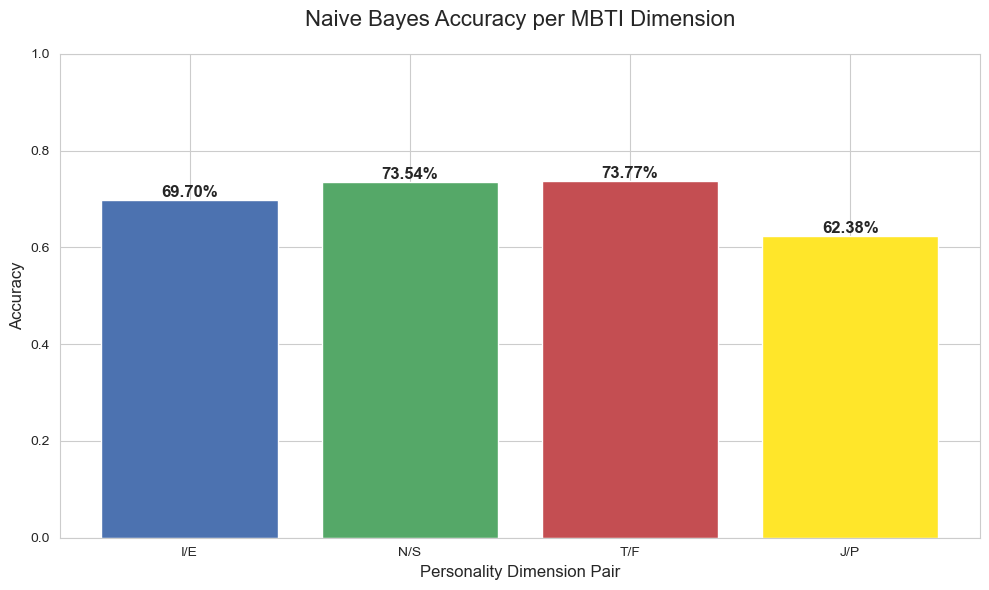


📈 Total Sum of Accuracies: 2.7939
📊 Average Accuracy: 69.85%
average f1 score: 0.6974


In [45]:
# --- STEP 3: Train the 4 Binary Models & Plot ---
print("\n🚀 Starting Naive Bayes Training...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
f1_scores = []

# Set a nice style for the plots
sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Processing {trait1} vs {trait2} ---")
    
    # Logic: If the label contains the second letter (e.g. 'E'), it's a 1. Else 0.
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Upsampling (Crucial for Naive Bayes)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y_binary)
    
    # Split Data (Using your specific test_size=0.18)
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.20, random_state=42
    )
    
    # Train with alpha tuning to prevent overfitting
    # Alpha adds smoothing - higher values = less overfitting but potentially lower accuracy
    clf = MultinomialNB(alpha=5.0)  # Default is 1.0, try values like 0.5, 1.0, 2.0
    clf.fit(X_train, y_train)
    
    # Evaluate on BOTH train and test to detect overfitting
    train_preds = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)

    current_f1 = f1_score(y_test, test_preds, average='macro')
    f1_scores.append(current_f1) 
    
    conf_mat = confusion_matrix(y_test, test_preds)
    
    results[f"{trait1}/{trait2}"] = test_acc
    
    print(f"   Train Accuracy: {train_acc:.2%}")
    print(f"   Test Accuracy:  {test_acc:.2%}")
    print(f"   Difference:     {(train_acc - test_acc):.2%}")
    if train_acc - test_acc > 0.05:
        print(f"   ⚠️  Possible overfitting detected!")
    print(f"📊 Macro F1-Score: {current_f1:.4f}")
    print(f"   Confusion Matrix:\n{conf_mat}")

# --- PLOTTING THE RESULTS ---
print("\n📊 Generating Bar Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

# Add title and labels
plt.title('Naive Bayes Accuracy per MBTI Dimension', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0) # Scale y-axis from 0 to 100%

# Add the percentage numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- SUM OF ACCURACIES ---
total_accuracy = sum(results.values())
avg_accuracy = total_accuracy / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)
print(f"\n📈 Total Sum of Accuracies: {total_accuracy:.4f}")
print(f"📊 Average Accuracy: {avg_accuracy:.2%}")
print(f"average f1 score: {avg_f1:.4f}")

In [46]:
# --- Final Summary ---
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 69.70%
N/S: 73.54%
T/F: 73.77%
J/P: 62.38%


## cross validation ||


🚀 Starting Naive Bayes Training with 5-Fold Cross-Validation...

--- Processing I vs E ---
   CV Accuracy: 63.57% (+/- 1.18%)
   CV F1-Score: 0.5888 (+/- 0.0101)
   Individual fold accuracies: ['64.32%', '65.09%', '63.83%', '62.88%', '61.70%']
   Confusion Matrix (full data):
[[4378 2156]
 [ 461 1467]]

--- Processing N vs S ---
   CV Accuracy: 67.40% (+/- 1.74%)
   CV F1-Score: 0.5636 (+/- 0.0175)
   Individual fold accuracies: ['66.63%', '67.99%', '64.66%', '67.73%', '69.98%']
   Confusion Matrix (full data):
[[5244 2040]
 [ 254  924]]

--- Processing T vs F ---
   CV Accuracy: 73.22% (+/- 0.99%)
   CV F1-Score: 0.7272 (+/- 0.0102)
   Individual fold accuracies: ['72.83%', '73.01%', '74.47%', '71.69%', '74.11%']
   Confusion Matrix (full data):
[[2701 1206]
 [ 802 3753]]

--- Processing J vs P ---
   CV Accuracy: 60.59% (+/- 1.36%)
   CV F1-Score: 0.5951 (+/- 0.0133)
   Individual fold accuracies: ['62.02%', '61.72%', '58.33%', '59.81%', '61.05%']
   Confusion Matrix (full data):
[[

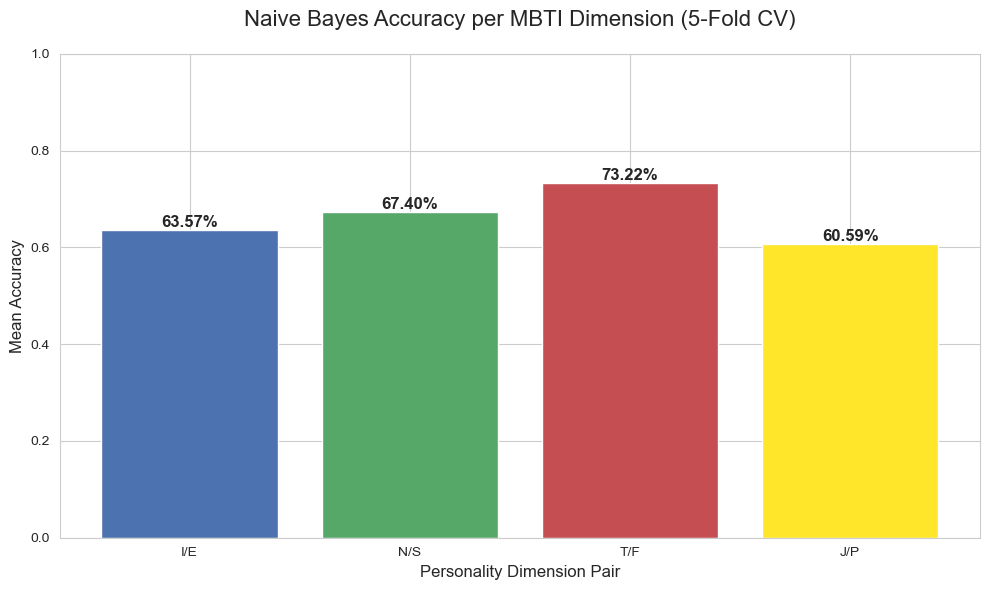


📈 Average CV Accuracy: 66.19%
📊 Average CV F1-Score: 0.6187


In [47]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# --- STEP 3: Train the 4 Binary Models with 5-Fold CV ---
print("\n🚀 Starting Naive Bayes Training with 5-Fold Cross-Validation...")
dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
f1_scores = []

# Set up 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set a nice style for the plots
sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Processing {trait1} vs {trait2} ---")
    
    # Create binary labels
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Create pipeline with upsampling and classifier
    # This ensures upsampling happens INSIDE each fold
    pipeline = ImbPipeline([
        ('sampler', RandomOverSampler(random_state=42)),
        ('classifier', MultinomialNB(alpha=5.0))
    ])
    
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(pipeline, X, y_binary, cv=cv, scoring='accuracy')
    cv_f1_scores = cross_val_score(pipeline, X, y_binary, cv=cv, scoring='f1_macro')
    
    # Calculate mean and std
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    mean_f1 = cv_f1_scores.mean()
    std_f1 = cv_f1_scores.std()
    
    results[f"{trait1}/{trait2}"] = mean_acc
    f1_scores.append(mean_f1)
    
    print(f"   CV Accuracy: {mean_acc:.2%} (+/- {std_acc:.2%})")
    print(f"   CV F1-Score: {mean_f1:.4f} (+/- {std_f1:.4f})")
    print(f"   Individual fold accuracies: {[f'{score:.2%}' for score in cv_scores]}")
    
    # Optional: Train on full dataset for confusion matrix visualization
    pipeline.fit(X, y_binary)
    y_pred_full = pipeline.predict(X)
    conf_mat = confusion_matrix(y_binary, y_pred_full)
    print(f"   Confusion Matrix (full data):\n{conf_mat}")

# --- PLOTTING THE RESULTS ---
print("\n📊 Generating Bar Graph...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

# Add title and labels
plt.title('Naive Bayes Accuracy per MBTI Dimension (5-Fold CV)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.ylim(0, 1.0)

# Add percentage numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- FINAL STATISTICS ---
avg_accuracy = sum(results.values()) / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)

print(f"\n📈 Average CV Accuracy: {avg_accuracy:.2%}")
print(f"📊 Average CV F1-Score: {avg_f1:.4f}")


cant get it better :( accept the poor f1 of n vs s --> too much imbalance